In [1]:
import cdsapi
import zipfile
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs

from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
pfns = PlottingFns()


In [4]:


dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["land_sea_mask"],
    "year": ["2025"],
    "month": ["08"],
    "time": ["00:00"],
    "data_format": "netcdf",
   # "download_format": "zip"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()

2025-11-25 17:33:57,454 INFO Request ID is d627d787-350b-4ce9-8791-2a80fdf02d0e
2025-11-25 17:33:57,513 INFO status has been updated to accepted
2025-11-25 17:34:11,093 INFO status has been updated to successful


c8517cce57bb168f2aed331b63d10ba3.nc:   0%|          | 0.00/762k [00:00<?, ?B/s]

'c8517cce57bb168f2aed331b63d10ba3.nc'

In [2]:
dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "mean_sea_level_pressure"
    ],
    "year": [
        "2003", "2004", "2005",
        "2006", "2007", "2008",
        "2009", "2010", "2011",
        "2012", "2013", "2014",
        "2015", "2016", "2017",
        "2018", "2019", "2020",
        "2021", "2022", "2023"
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-50, -180, -90, 180]
}

client = cdsapi.Client()
fname=client.retrieve(dataset, request).download()


2025-04-03 14:37:09,132 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-03 14:37:09,134 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-04-03 14:37:09,135 WARNING [2024-04-03T00:00:00] System is in degraded status due to underlaying infrastructure problems. Please follow status [here](https://status.ecmwf.int/)
2025-04-03 14:37:09,408 INFO Request ID is b456d66a-b65c-4adb-8a00-94e4009a9683
2025-04-03 14:37:09,484 INFO status has been updated to accepted
2025-04-03 14:37:14,494 INFO status has been updated to running
2025-04-03 14:37:23,102 INFO status has been updated to successful


ef25db236e60a21a34ee2e0b4631d366.nc:   0%|          | 0.00/262M [00:00<?, ?B/s]

In [3]:
fname

'ef25db236e60a21a34ee2e0b4631d366.nc'

In [8]:
ds = xr.open_dataset(fname)

In [13]:
ds

<xarray.Dataset> Size: 701MB
Dimensions:     (valid_time: 252, latitude: 161, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2kB 2003-01-01 ... 2023-12-01
  * latitude    (latitude) float64 1kB -50.0 -50.25 -50.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    expver      (valid_time) <U4 4kB ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 234MB ...
    u10         (valid_time, latitude, longitude) float32 234MB ...
    v10         (valid_time, latitude, longitude) float32 234MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [28]:
ds_sample.v10

<xarray.DataArray 'v10' (latitude: 161, longitude: 1440)> Size: 927kB
array([[-1.928447, -1.911357, -1.897197, ..., -1.977275, -1.963603, -1.945048],
       [-1.993388, -1.973857, -1.961162, ..., -2.029033, -2.020732, -2.009013],
       [-2.04124 , -2.029033, -2.017314, ..., -2.072001, -2.063212, -2.051494],
       ...,
       [ 2.923604,  2.935811,  2.948018, ...,  2.886495,  2.898702,  2.910909],
       [ 2.785909,  2.792256,  2.798604, ...,  2.767842,  2.773702,  2.780049],
       [ 0.082295,  0.082295,  0.082295, ...,  0.082295,  0.082295,  0.082295]],
      dtype=float32)
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2012-01-01
  * latitude    (latitude) float64 1kB -50.0 -50.25 -50.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             166
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      231840
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre V wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [37]:
ds_sample.latitude

<xarray.DataArray 'latitude' (latitude: 161)> Size: 1kB
array([-50.  , -50.25, -50.5 , -50.75, -51.  , -51.25, -51.5 , -51.75, -52.  ,
       -52.25, -52.5 , -52.75, -53.  , -53.25, -53.5 , -53.75, -54.  , -54.25,
       -54.5 , -54.75, -55.  , -55.25, -55.5 , -55.75, -56.  , -56.25, -56.5 ,
       -56.75, -57.  , -57.25, -57.5 , -57.75, -58.  , -58.25, -58.5 , -58.75,
       -59.  , -59.25, -59.5 , -59.75, -60.  , -60.25, -60.5 , -60.75, -61.  ,
       -61.25, -61.5 , -61.75, -62.  , -62.25, -62.5 , -62.75, -63.  , -63.25,
       -63.5 , -63.75, -64.  , -64.25, -64.5 , -64.75, -65.  , -65.25, -65.5 ,
       -65.75, -66.  , -66.25, -66.5 , -66.75, -67.  , -67.25, -67.5 , -67.75,
       -68.  , -68.25, -68.5 , -68.75, -69.  , -69.25, -69.5 , -69.75, -70.  ,
       -70.25, -70.5 , -70.75, -71.  , -71.25, -71.5 , -71.75, -72.  , -72.25,
       -72.5 , -72.75, -73.  , -73.25, -73.5 , -73.75, -74.  , -74.25, -74.5 ,
       -74.75, -75.  , -75.25, -75.5 , -75.75, -76.  , -76.25, -76.5 , -76.75,
       -77.  , -77.25, -77.5 , -77.75, -78.  , -78.25, -78.5 , -78.75, -79.  ,
       -79.25, -79.5 , -79.75, -80.  , -80.25, -80.5 , -80.75, -81.  , -81.25,
       -81.5 , -81.75, -82.  , -82.25, -82.5 , -82.75, -83.  , -83.25, -83.5 ,
       -83.75, -84.  , -84.25, -84.5 , -84.75, -85.  , -85.25, -85.5 , -85.75,
       -86.  , -86.25, -86.5 , -86.75, -87.  , -87.25, -87.5 , -87.75, -88.  ,
       -88.25, -88.5 , -88.75, -89.  , -89.25, -89.5 , -89.75, -90.  ])
Coordinates:
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2012-01-01
  * latitude    (latitude) float64 1kB -50.0 -50.25 -50.5 ... -89.5 -89.75 -90.0
    expver      <U4 16B '0001'
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

AttributeError: Quiver.set() got an unexpected keyword argument 'regrid_shape'

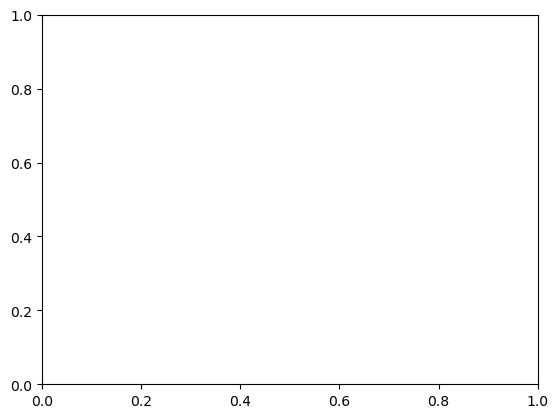

In [39]:
ds_sample.sel(latitude=slice(-50,-60),longitude=slice(-5,5)).plot.quiver(x='longitude',y='latitude',u='u10',v='v10', regrid_shape=20)

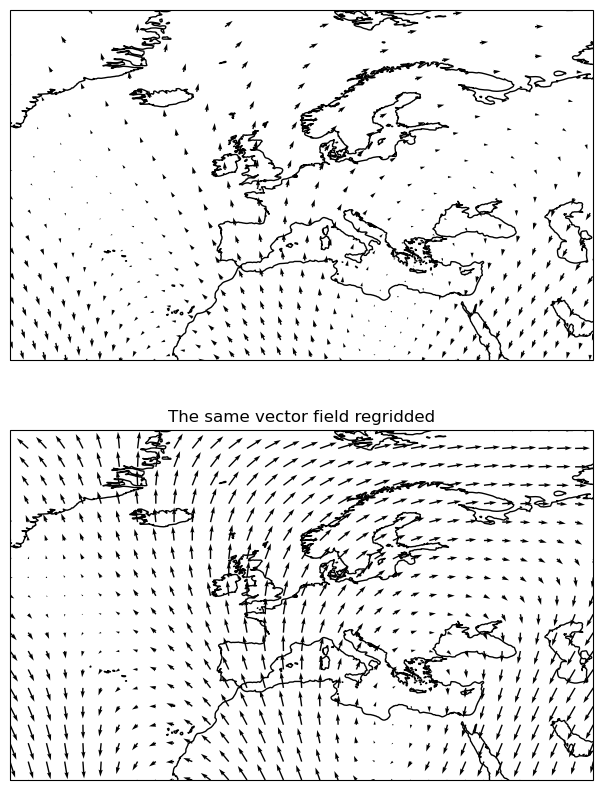

In [40]:

def sample_data(shape=(20, 30)):
    """
    Return ``(x, y, u, v, crs)`` of some vector data
    computed mathematically. The returned CRS will be a North Polar
    Stereographic projection, meaning that the vectors will be unevenly
    spaced in a PlateCarree projection.

    """
    crs = ccrs.NorthPolarStereo()
    scale = 1e7
    x = np.linspace(-scale, scale, shape[1])
    y = np.linspace(-scale, scale, shape[0])

    x2d, y2d = np.meshgrid(x, y)
    u = 10 * np.cos(2 * x2d / scale + 3 * y2d / scale)
    v = 20 * np.cos(6 * x2d / scale)

    return x, y, u, v, crs


fig = plt.figure(figsize=(8, 10))

x, y, u, v, vector_crs = sample_data(shape=(50, 50))
ax1 = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax1.coastlines('50m')
ax1.set_extent([-45, 55, 20, 80], ccrs.PlateCarree())
ax1.quiver(x, y, u, v, transform=vector_crs)

ax2 = fig.add_subplot(2, 1, 2, projection=ccrs.PlateCarree())
ax2.set_title('The same vector field regridded')
ax2.coastlines('50m')
ax2.set_extent([-45, 55, 20, 80], ccrs.PlateCarree())
ax2.quiver(x, y, u, v, transform=vector_crs, regrid_shape=20)

In [51]:
x,y,u,v,vec=sample_data()

In [61]:
print(x.shape)
print(y.shape)
print(u.shape)
print(v.shape)

print(ds_sample.longitude.shape)
print(ds_sample.latitude.shape)
print(ds_sample.u10.shape)
print(ds_sample.v10.shape)

(30,)
(20,)
(20, 30)
(20, 30)
(1440,)
(161,)
(161, 1440)
(161, 1440)


ValueError: x, y, u and v arrays must be the same shape

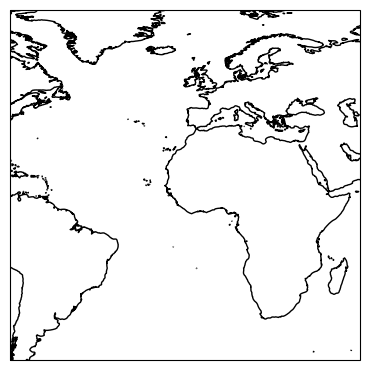

In [49]:
# fig, ax = plt.subplots(figsize=(10,10),subplot_kw={"projection":ccrs.SouthPolarStereo()})
# t_sample = pd.Timestamp(2012,1,1)
# ds_sample = ds.sel(valid_time=t_sample,method='nearest')
# pfns.sp(ax=ax,da=ds_sample.msl)
# ax.quiver(ds_sample.longitude,ds_sample.latitude,ds_sample.u10,ds_sample.v10,transform=ccrs.PlateCarree())



fig = plt.figure(figsize=(8, 10))

x = ds.longitude
y = ds.latitude
u = ds.u10
v = ds.v10
vector_crs = ccrs.SouthPolarStereo()

ax1 = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax1.coastlines('50m')
ax1.set_extent([-75, 55, -50, 80], ccrs.PlateCarree())
ax1.quiver(x, y, u, v, transform=vector_crs)

ax2 = fig.add_subplot(2, 1, 2, projection=ccrs.PlateCarree())
ax2.set_title('The same vector field regridded')
ax2.coastlines('50m')
ax2.set_extent([-75, 55, -50, 80], ccrs.PlateCarree())
ax2.quiver(x, y, u, v, transform=vector_crs, regrid_shape=20)

In [ ]:
dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind"
    ],
    "year": ["2007"],
    "month": ["02"],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "zip",
    "area": [-50, -180, -90, 180]
}

client = cdsapi.Client()
rtn=client.retrieve(dataset, request).download()

2025-04-03 12:16:37,183 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-03 12:16:37,184 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-04-03 12:16:37,424 INFO Request ID is 7ae1d881-edba-41d0-8e88-037ca094b543
2025-04-03 12:16:37,498 INFO status has been updated to accepted
